In [1]:
import joblib
import pandas as pd
import shap

model = joblib.load("../models/house_price_xgboost.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [2]:
trained_xgb = model.named_steps["model"]
preprocessor = model.named_steps["preprocessor"]

In [3]:
# load dataset

df = pd.read_csv(
    "../dataset/processed/feature_engineered_house_prices.csv"
)

features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "TYPE",
    "STATE",
    "LOCALITY"
]

X = df[features]

In [4]:
# transform the dataset

X_transformed = preprocessor.transform(X)

In [5]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

44
['categorical__TYPE_House for sale' 'categorical__TYPE_Villa for sale'
 'categorical__STATE_Colombo' 'categorical__LOCALITY_Athurugiriya'
 'categorical__LOCALITY_Awissawella'
 'categorical__LOCALITY_Bambalapitiya '
 'categorical__LOCALITY_Battaramulla'
 'categorical__LOCALITY_Boralesgamuwa' 'categorical__LOCALITY_Colombo 6'
 'categorical__LOCALITY_Colombo 7' 'categorical__LOCALITY_Colombo 8'
 'categorical__LOCALITY_Colombo 9' 'categorical__LOCALITY_Dehiwala'
 'categorical__LOCALITY_Dematagoda' 'categorical__LOCALITY_Homagama'
 'categorical__LOCALITY_Kaduwela' 'categorical__LOCALITY_Kesbewa'
 'categorical__LOCALITY_Kirulapona' 'categorical__LOCALITY_Kohuwala'
 'categorical__LOCALITY_Kolonnawa']


In [6]:
# Shap explainer

explainer = shap.TreeExplainer(trained_xgb)

shap_values = explainer(
    X_transformed
)

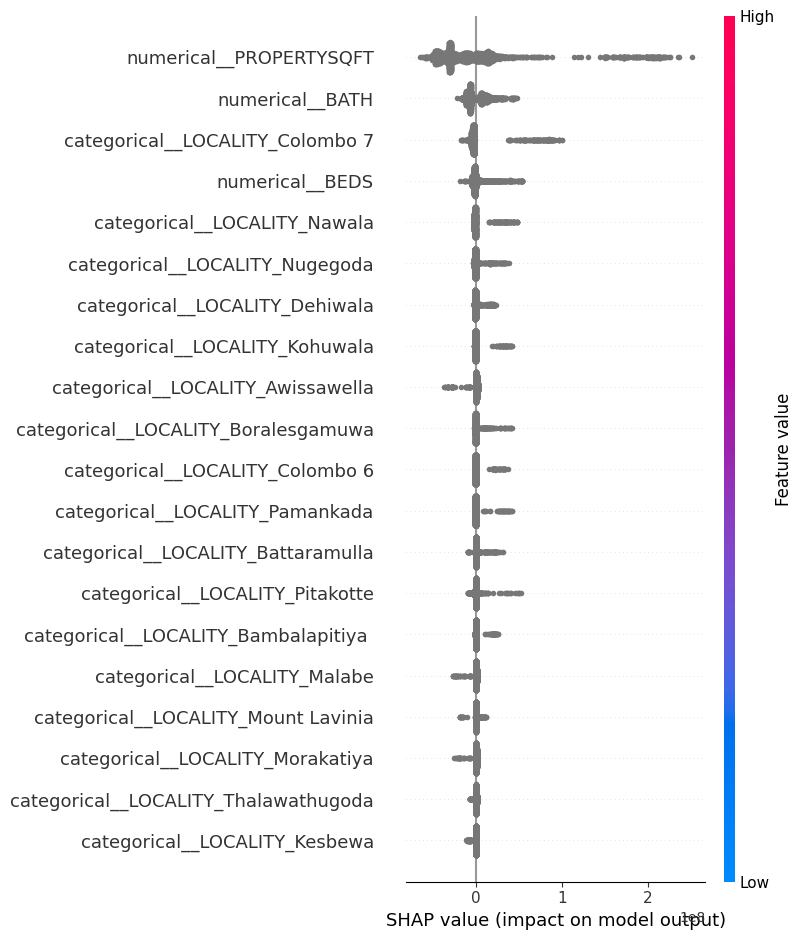

In [7]:
# summery plot

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

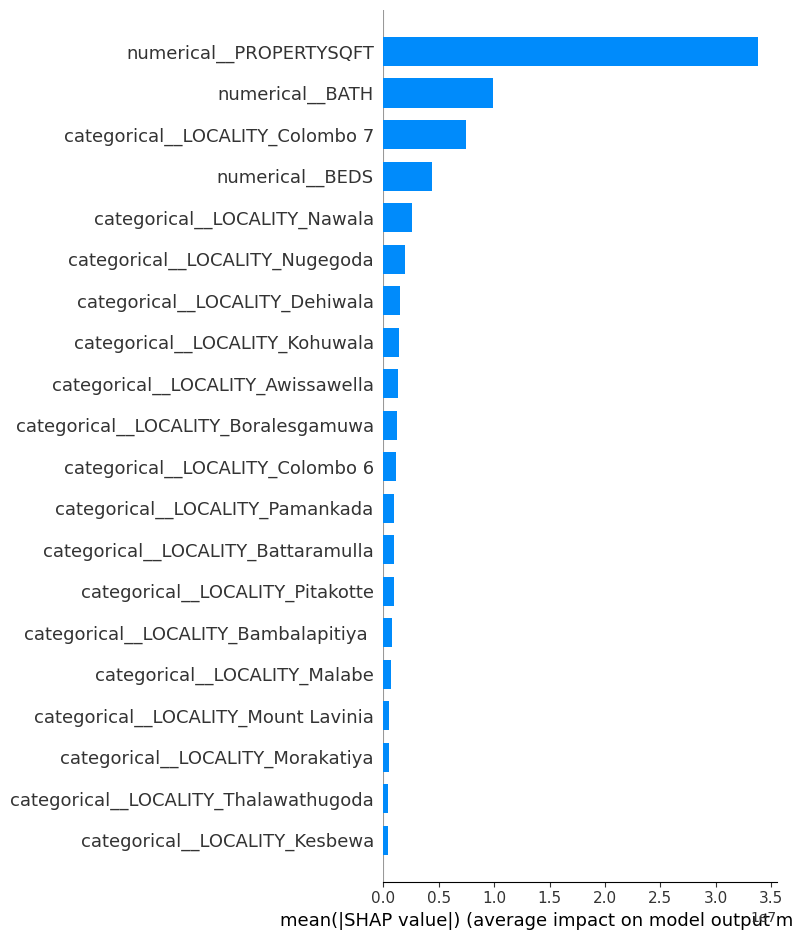

In [8]:
# bar plot

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)